# PPOCR v3 text detection model

## 1. Set up environment

In [ ]:
from setuptools.tests.contexts import save_paths
!nvidia-smi

Import Torch

In [ ]:
try:
    import torch
    import torchvision

    from torch import nn
    from torchvision import transforms
    print(torch.__version__)
    print(torchvision.__version__)
except:
    %pip install torch
    import torch
    import torchvision
    from torch import nn
    from torchvision import transforms
    print(torch.__version__)
    print(torchvision.__version__)

Import Paddle

In [ ]:
try:
    import paddle
    print(f"PaddlePaddle version: {paddle.__version__}")
except:
    print("[INFO] requirements not downloaded.")
    %pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu129/
    import paddle
    print(f"PaddlePaddle version: {paddle.__version__}")

Set-up CTW dataloader for text detection

In [5]:
from pathlib import Path

text_det_model_dir = Path("ch_ppocr_mobile_v2.0_det_train")
config_file_dir = text_det_model_dir / "ch_det_mv3_db_v2.0.yml"
weights_dir = text_det_model_dir / "best_accuracy.pdparams"
optimizer_dir = text_det_model_dir / "best_accuracy.pdopt"
train_metadata_dir = text_det_model_dir / "best_accuracy.states"

In [6]:
data_root_dir = Path("ch_char_datasets")

train_dir = data_root_dir / "images-trainval" / "train"
test_dir = data_root_dir /  "images-test" / "test"
annotation_dir = data_root_dir / "ctw-annotations"

train_annotation_file = annotation_dir / "train.jsonl"
test_annotation_file = annotation_dir / "test_cls.jsonl"
val_annotation_file = annotation_dir / "val.jsonl"

In [7]:
import os
import json
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


class CTWDataset(Dataset):
    """
    Chinese Text in the Wild (CTW) Dataset
    """

    def __init__(self, image_dir, dataset_type, annotation_file, transform=None, include_ignore=False):
        """
        Args:
            image_dir: train datasets / test datasets directory
            annotation_file: Path to JSONL annotation file
            transform:  Optional image transforms
            include_ignore: Whether to include ignored regions
        """
        self.image_dir = image_dir
        self.dataset_type = dataset_type
        self.transform = transform
        self.include_ignore = include_ignore
        self.annotations = self._load_jsonl(annotation_file)
        print(f"Loaded {len(self.annotations)} images from {annotation_file}")

    def _load_jsonl(self, file_path):
        """Load annotations from JSONL file (one JSON per line)."""
        annotations = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                if line.strip():
                    annotations.append(json.loads(line))
        return annotations

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, idx):
        ann = self.annotations[idx]

        # Load image
        img_path = os.path.join(self.image_dir, ann['file_name'])
        image = Image.open(img_path).convert('RGB')
        original_size = image.size  # (width, height)

        # Extract detection targets
        if self.dataset_type == 'test':
            target = self._get_test_target(ann, original_size)
        else:
          target = self._get_train_target(ann, original_size)

        if self.transform:
            image = self.transform(image)

        return image, target

    def _get_train_target(self, ann, original_size):
        """Extract bounding boxes, polygons, and labels."""
        boxes = []
        polygons = []
        labels = []
        texts = []
        attributes_list = []
        is_chinese_list = []

        # annotations is a nested list: sentences -> characters
        for sentence in ann['annotations']:
            for char_info in sentence:
                # Get adjusted_bbox [x, y, width, height] and convert to [x1, y1, x2, y2]
                adj_bbox = char_info['adjusted_bbox']
                x, y, w, h = adj_bbox
                box = [x, y, x + w, y + h]
                boxes.append(box)

                # Get polygon points [[x1,y1], [x2,y2], [x3,y3], [x4,y4]]
                polygon = char_info['polygon']
                # Flatten to [x1, y1, x2, y2, x3, y3, x4, y4]
                flat_polygon = [coord for point in polygon for coord in point]
                polygons.append(flat_polygon)

                # Text and attributes
                texts.append(char_info['text'])
                labels.append(1)  # 1 = text class
                attributes_list.append(char_info. get('attributes', []))
                is_chinese_list.append(char_info.get('is_chinese', True))

        # Handle ignore regions if needed
        ignore_boxes = []
        if self.include_ignore:
            for ignore_info in ann. get('ignore', []):
                if 'bbox' in ignore_info:
                    x, y, w, h = ignore_info['bbox']
                    ignore_boxes.append([x, y, x + w, y + h])

        target = {
            'boxes': torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
            'polygons': torch.tensor(polygons, dtype=torch.float32) if polygons else torch.zeros((0, 8)),
            'labels': torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            'texts': texts,
            'attributes': attributes_list,
            'is_chinese': is_chinese_list,
            'ignore_boxes': torch.tensor(ignore_boxes, dtype=torch.float32) if ignore_boxes else torch.zeros((0, 4)),
            'image_id': ann['image_id'],
            'original_size':  original_size,  # (width, height)
        }
        return target

    def _get_test_target(self, ann, original_size):

      boxes = []
      polygons = []
      labels = []

      for char_info in ann['proposals']:
          adj_bbox = char_info['adjusted_bbox']
          x, y, w, h = adj_bbox
          box = [x, y, x + w, y + h]
          boxes.append(box)

          polygon = char_info['polygon']
          flat_polygon = [coord for point in polygon for coord in point]
          polygons.append(flat_polygon)

          labels.append(1)  # 1 = text class

      target = {
          'boxes': torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0, 4)),
          'polygons': torch.tensor(polygons, dtype=torch.float32) if polygons else torch. zeros((0, 8)),
          'labels': torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
          'texts': None,  # No text labels in test set
          'attributes': None,
          'is_chinese': None,
          'ignore_boxes': torch.zeros((0, 4)),
          'image_id': ann['image_id'],
          'file_name': ann['file_name'],
          'original_size': original_size,
          'mode':  'test'
        }

      return target


def detection_collate_fn(batch):
    """Custom collate function for variable-size targets."""
    images = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    return images, targets

In [8]:
## Create detection dataloaders

def create_ctw_dataloaders(
    train_dir,
    train_file,
    val_file,
    test_dir,
    test_file,
    batch_size=16,
    num_workers=4,
    image_size=(512, 512)
):
    """
    Create CTW dataloaders for training, validation, and testing.

    Args:
        root_dir: Directory containing image files
        train_file: Path to train. jsonl
        val_file: Path to val.jsonl
        test_file: Path to test_cls.jsonl (optional)
        batch_size: Batch size
        num_workers: Number of data loading workers
        image_size: Target image size (height, width)

    Returns:
        train_loader, val_loader, test_loader (test_loader is None if test_file not provided)
    """

    # Training transforms (with augmentation)
    train_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.RandomHorizontalFlip(p=0.3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Validation/Test transforms (no augmentation)
    eval_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms. Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create datasets
    train_dataset = CTWDataset(train_dir, 'train',train_file, transform=train_transform)
    val_dataset = CTWDataset(train_dir, 'validation', val_file, transform=eval_transform)
    test_dataset = CTWDataset(test_dir, 'test', test_file, transform=eval_transform)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=detection_collate_fn,
        pin_memory=True,
        drop_last=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=detection_collate_fn,
        pin_memory=True
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        collate_fn=detection_collate_fn,
        pin_memory=True
    )
    return train_loader, val_loader, test_loader

In [9]:
# Test dataloaders

train_dataloader, val_dataloader, test_dataloader = create_ctw_dataloaders(
    train_dir=train_dir,
    train_file=train_annotation_file,
    val_file=val_annotation_file,
    test_dir=test_dir,
    test_file=test_annotation_file,
    num_workers=os.cpu_count()
)

Loaded 24290 images from ch_char_datasets/ctw-annotations/train.jsonl
Loaded 1597 images from ch_char_datasets/ctw-annotations/val.jsonl
Loaded 3269 images from ch_char_datasets/ctw-annotations/test_cls.jsonl



=== Testing Train DataLoader ===


[2026-01-23 13:33:17,509] [ WARNING] image.py:661 - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..1.6988237].


Batch images shape: torch.Size([16, 3, 512, 512])
Number of samples in batch: 16

First sample:
  - Image ID: 3047171
  - Number of text boxes: 18
  - Boxes shape: torch.Size([18, 4])
  - Polygons shape: torch.Size([18, 8])
  - First 3 texts: ['牛', '肉', '面']
  - First 3 attributes:  [['raised'], ['raised'], ['raised']]


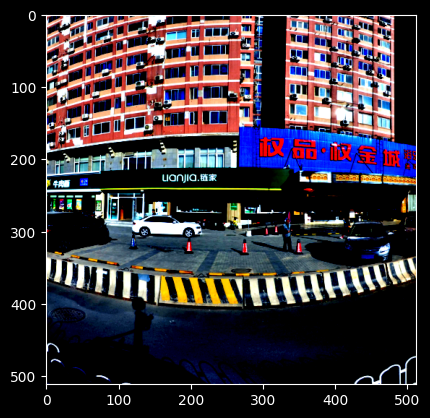

In [10]:
# Test dataloader
import matplotlib.pyplot as plt

print("\n=== Testing Train DataLoader ===")
for images, targets in train_dataloader:
    print(f"Batch images shape: {images.shape}")
    print(f"Number of samples in batch: {len(targets)}")

    # Inspect first sample
    t = targets[0]
    print(f"\nFirst sample:")
    print(f"  - Image ID: {t['image_id']}")
    print(f"  - Number of text boxes: {t['boxes'].shape[0]}")
    print(f"  - Boxes shape: {t['boxes'].shape}")
    print(f"  - Polygons shape: {t['polygons'].shape}")
    print(f"  - First 3 texts: {t['texts'][:3]}")
    print(f"  - First 3 attributes:  {t['attributes'][:3]}")

    plt.imshow(images[0].permute(1, 2, 0))
    plt.show()

    break

In [ ]:
print("\n=== Testing Test DataLoader ===")
for images, targets in test_dataloader:
    print(f"Batch images shape: {images.shape}")
    print(f"Number of samples in batch: {len(targets)}")

    # Inspect first sample
    t = targets[0]
    print(f"\nFirst sample:")
    print(f"  - Image ID: {t['image_id']}")
    print(f"  - Number of text boxes: {t['boxes'].shape[0]}")
    print(f"  - Boxes shape: {t['boxes'].shape}")
    print(f"  - Polygons shape: {t['polygons'].shape}")
    print(f"  - File Name: {t['file_name']}")

    plt.imshow(images[0].permute(1, 2, 0))
    plt.show()

    break

Test PPOCRV5 text-detection pre-train performance

In [ ]:
try:
    import paddleocr
except:
    %pip install paddleocr
    import paddleocr

In [ ]:
# Create PPOCR mobile text detection model (PP-OCRv5_mobile_det)
import paddleocr
from paddleocr import TextDetection
paddleocrv5 = TextDetection(model_name="PP-OCRv5_mobile_det")

In [ ]:
# randomly generate 5 index
import random
random_index = random.sample(range(15), 5)
print(f"Random index: {random_index}")

# predict on these 5 images

# clear output directory
%rm -r output
%rm -r output-json

for index in random_index:
    image, target = test_dataloader.dataset[index]
    image_path = f'ch_char_datasets/images-test/test/{target['file_name']}'
    print(f"  - Image ID: {target['image_id']}")
    output = paddleocrv5.predict(image_path, batch_size=1)

    for res in output:
        res.print()
        res.save_to_img(save_path=f"./output-ctw/{index}.png")
        res.save_to_json(save_path=f"./output-ctw-json/{index}.json")

In [44]:
import os
print(f'output dir: {os.listdir('./output')}')
print(f'output-json dir: {os.listdir('./output-json')}')

output dir: ['1.png', '13.png', '2.png', '6.png', '7.png']
output-json dir: ['1.json', '13.json', '2.json', '6.json', '7.json']


In [ ]:
# print result from output
import json
from PIL import Image

for image in os.listdir('./output'):
    file_name = image.split('.')[0]
    res_json = json.load(open(f'./output-json/{file_name}.json'))

    image_path = f'./output/{image}'
    image = Image.open(image_path)

    print(f'score: {res_json["dt_scores"]}')
    image.show()

## Check PaddleOCR model on handwritten text datasets

## Fine tuning model

As we can see, PaddleOCRV5 mobile version is generally reliable for flat surface text reading such as signs and boards, but fails on curved texts and some vertical texts. PaddleOCRv5 mobile is also prone to false positives as it is not a highly accurate model as the server one.

We can probably do a little better with some training

In [17]:
try:
    from PaddleOCR.paddleocr import PaddleOCR
except:
    print("PaddleOCR not installed")
    !git clone https://github.com/PaddlePaddle/PaddleOCR
    %pip install -r requirements.txt

In [ ]:
 %cd PaddleOCR
 print(f"current working directory: {os.getcwd()}")
 %pip install -r requirements.txt

In [ ]:
!python3 -m pip install paddlepaddle-gpu==3.3.0 -i https://www.paddlepaddle.org.cn/packages/stable/cu118/


The bottom train does not work as the original training file has key mismatch. If have time, modify the annotation file to fit the training

In [ ]:
!python3 PaddleOCR/tools/train.py -c ./pp-ocrv5_mobile_det/PP-OCRv5_mobile_det.yml \
    -o Global.pretrained_model=./pp-ocrv5_mobile_det/PP-OCRv5_mobile_det_pretrained.pdparams \
    Train.dataset.data_dir=./ch_char_datasets/images-trainval/train \
    Train.dataset.label_file_list='[./ch_char_datasets/ctw-annotations/train.jsonl]' \
    Eval.dataset.data_dir=./ch_char_datasets/images-trainval/train \
    Eval.dataset.label_file_list='[./ch_char_datasets/ctw-annotations/val.jsonl]'

## TODO

Forget about training model for now. Focus on comparing performance of text detection model & text recognition model of
- PaddleOCR
- TesseractOCR and
- Thulium
